In [1]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = 'data_galah4'

In [2]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
# from torchsummary import summary
import helper
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# test for what computing device is used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [5]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

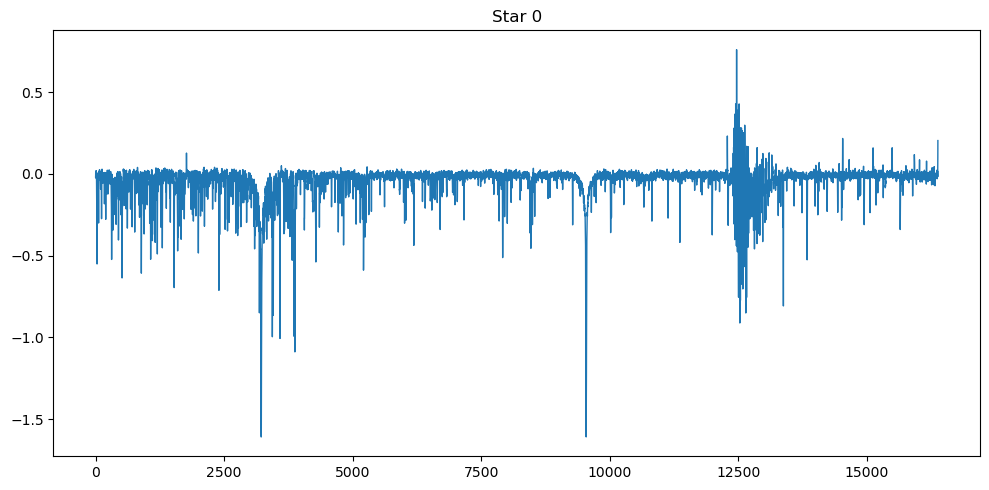

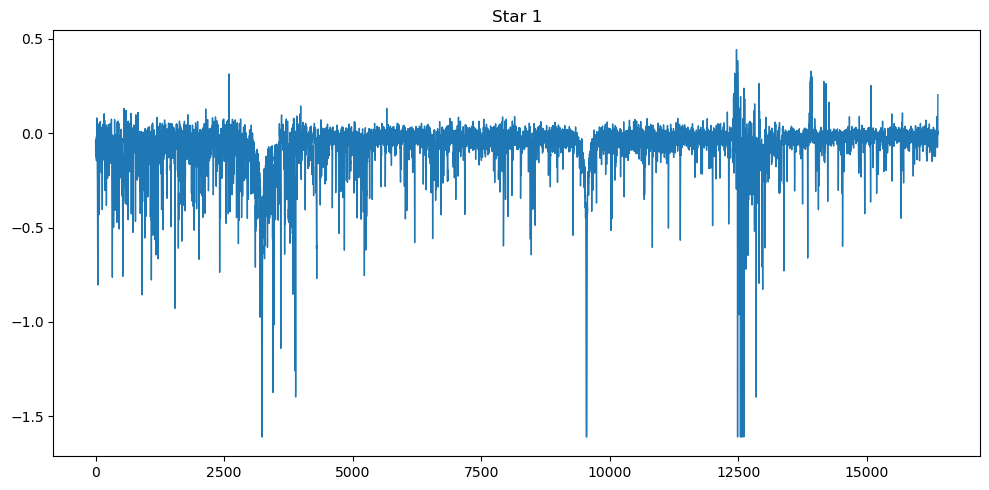

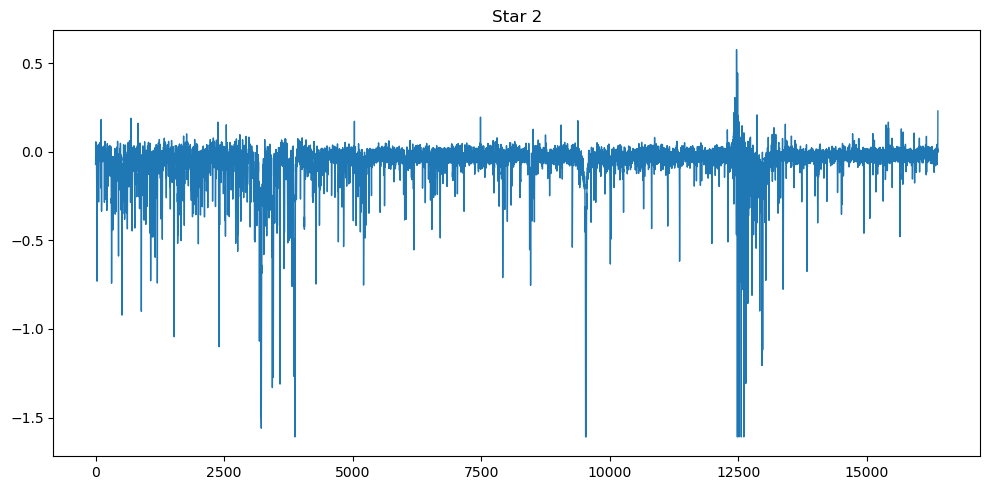

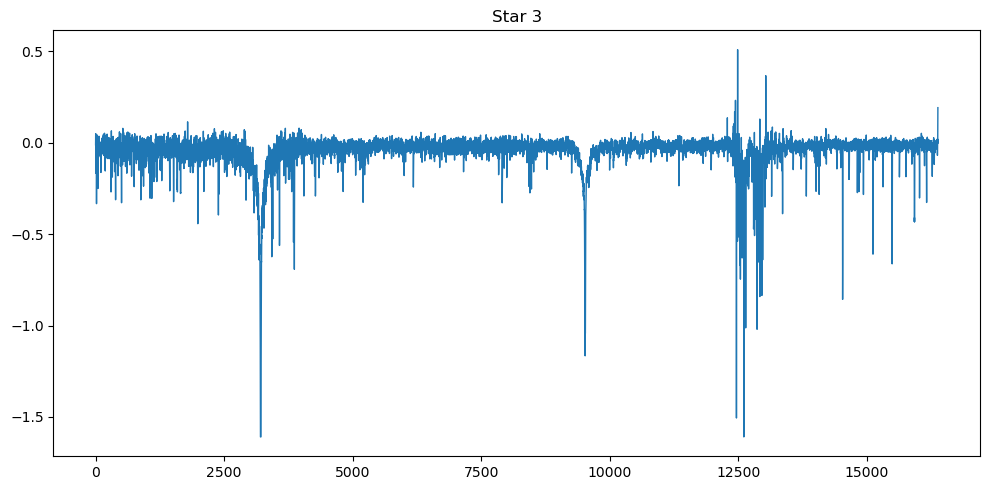

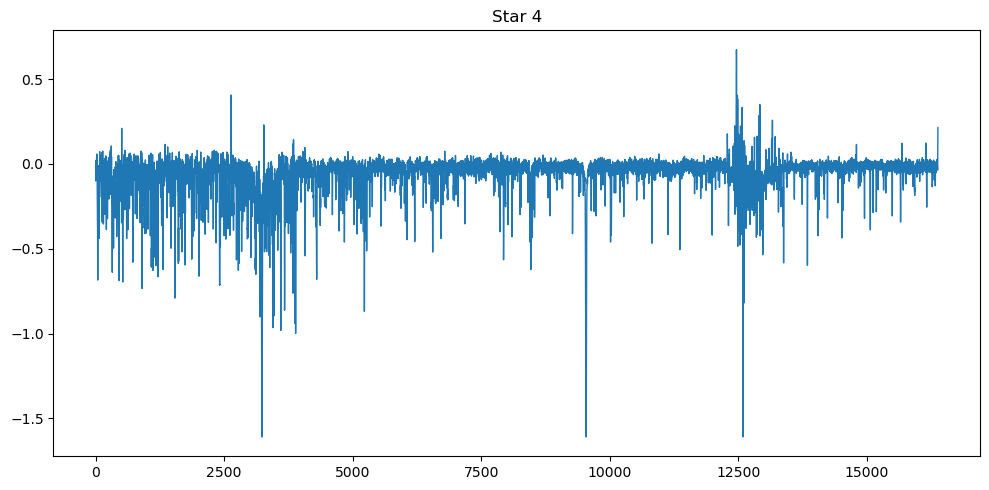

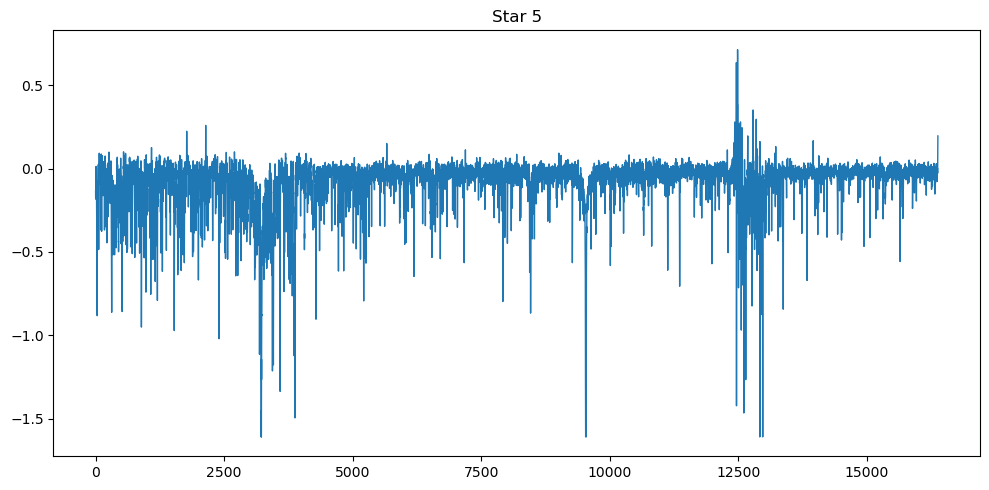

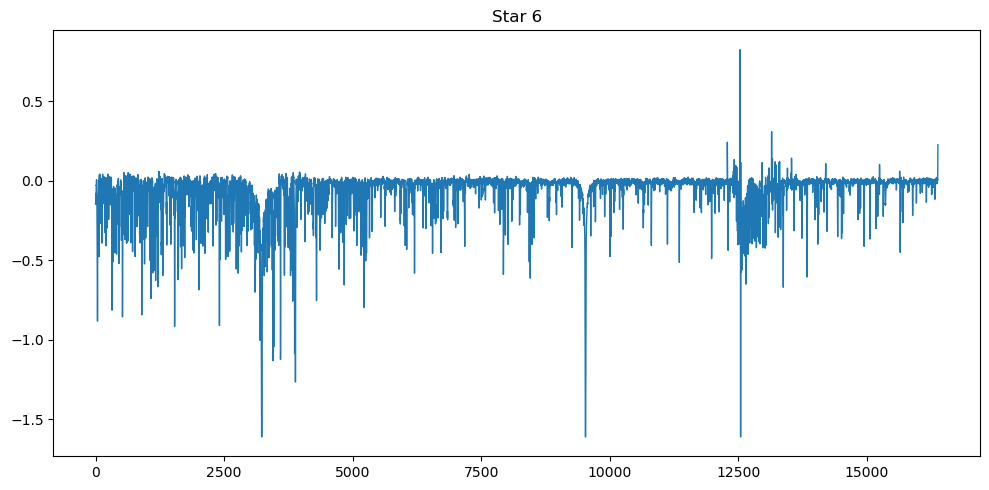

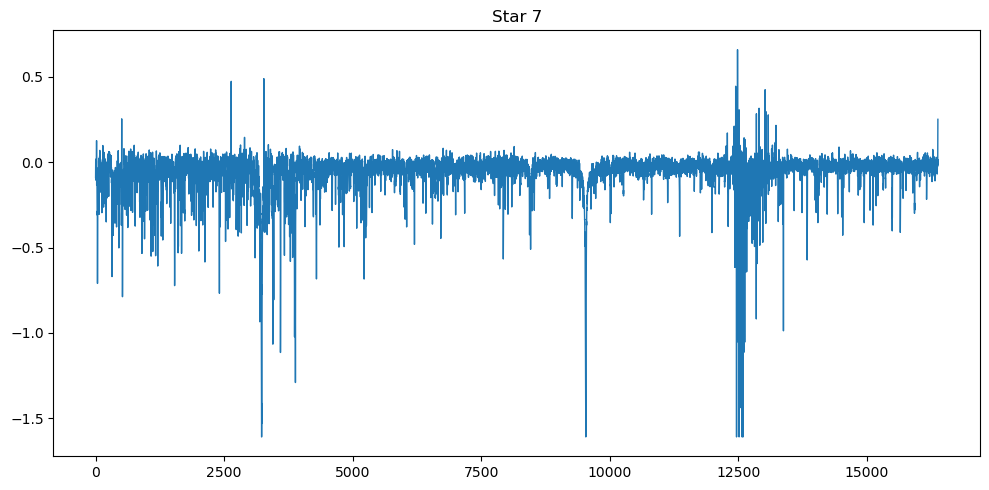

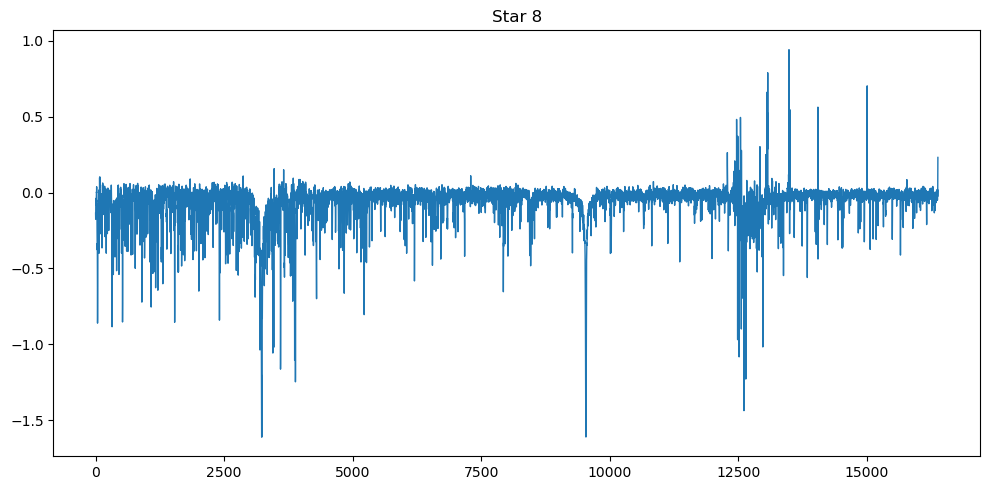

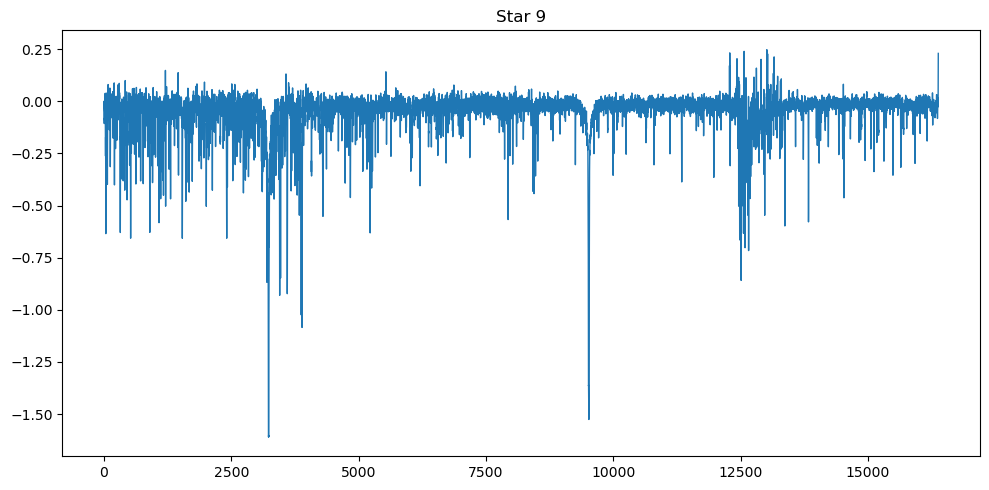

In [6]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()

In [7]:
# find out shape of the spectra:
print(np.shape(spectra))

(8914, 16384)


In [8]:
# load data and split into train, validation and test
train_size = int(0.7 * len(spectra))
val_size = int(0.15 * len(spectra))
test_size = len(spectra) - train_size - val_size
# scale the labels
scaler = StandardScaler()
labels_scaled = scaler.fit_transform(labels)
# combine spectra and labels:
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels_scaled, dtype=torch.float32)
full_dataset = TensorDataset(spectra_tensor, labels_tensor)
# do the actual split
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

# create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
# build CNN
# What do we need for the Model?
# Convolutional layer
# Activation function
# Fully connected layers

class CNN(nn.Module):
  def __init__(self):
    """
    Defining the structure of the CNN.
    """
    super(CNN, self).__init__()

  # Grouping the feature extraction layers
    self.feature_extractor = nn.Sequential(
        nn.Conv1d(1, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Conv1d(16, 32, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(2)
    )
    # define output size
    self.regressor = nn.LazyLinear(out_features=3)

  def forward(self, x):
      x = self.feature_extractor(x)
      x = x.view(x.size(0), -1)
      x = self.regressor(x)
      return x


In [10]:
# Initialize network
model = CNN().to(device)

# We grab a single batch from the train_loader to initialize the weights
dummy_inputs, _ = next(iter(train_loader))
dummy_inputs = dummy_inputs.to(device)

# Inject the missing channel dimension: [32, 16384] -> [32, 1, 16384]
dummy_inputs = dummy_inputs.unsqueeze(1)

# Actually execute the dummy pass to initialize LazyLinear
_ = model(dummy_inputs)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [11]:
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_loss = []
val_loss = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for inputs, targets in train_loader:
        # Both inputs and targets go to the GPU/CPU
        # Targets should be shape [batch_size, 3]
        inputs = inputs.to(device)
        targets = targets.to(device)

        inputs = inputs.unsqueeze(1)

        optimizer.zero_grad()

        # Forward pass: Returns a single tensor with all 3 predictions
        predictions = model(inputs)

        # Calculate loss directly on the combined tensors
        loss = criterion(predictions, targets)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    # evaluate model performance
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0

    # Disable gradient calculation to save memory and speed up
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            inputs = inputs.unsqueeze(1)

            predictions = model(inputs)
            val_batch_loss = criterion(predictions, targets)

            running_val_loss += val_batch_loss.item()

    # Calculate average losses
    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    train_loss.append(avg_train_loss)
    val_loss.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch [1/50] | Train Loss: 1.5280 | Val Loss: 0.5225
Epoch [2/50] | Train Loss: 0.2849 | Val Loss: 0.1513
Epoch [3/50] | Train Loss: 0.1267 | Val Loss: 0.1104
Epoch [4/50] | Train Loss: 0.0884 | Val Loss: 0.0958
Epoch [5/50] | Train Loss: 0.0733 | Val Loss: 0.0803
Epoch [6/50] | Train Loss: 0.0675 | Val Loss: 0.0956
Epoch [7/50] | Train Loss: 0.0617 | Val Loss: 0.0921
Epoch [8/50] | Train Loss: 0.0571 | Val Loss: 0.0717
Epoch [9/50] | Train Loss: 0.0493 | Val Loss: 0.0758
Epoch [10/50] | Train Loss: 0.0436 | Val Loss: 0.0715
Epoch [11/50] | Train Loss: 0.0416 | Val Loss: 0.0655
Epoch [12/50] | Train Loss: 0.0420 | Val Loss: 0.0681
Epoch [13/50] | Train Loss: 0.0411 | Val Loss: 0.0724
Epoch [14/50] | Train Loss: 0.0389 | Val Loss: 0.0605
Epoch [15/50] | Train Loss: 0.0352 | Val Loss: 0.0688
Epoch [16/50] | Train Loss: 0.0301 | Val Loss: 0.0657
Epoch [17/50] | Train Loss: 0.0292 | Val Loss: 0.0694
Epoch [18/50] | Train Loss: 0.0300 | Val Loss: 0.0670
Epoch [19/50] | Train Loss: 0.0343 | 

ValueError: x and y must have same first dimension, but have shapes (50,) and (1,)

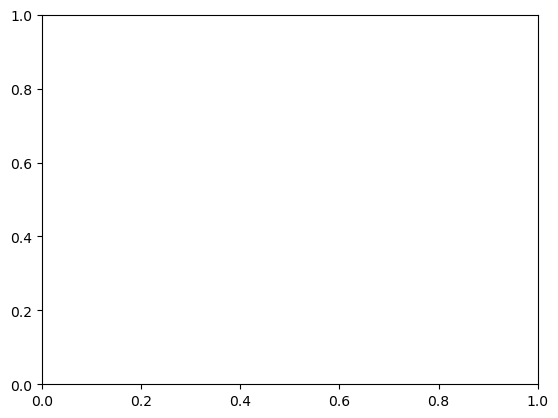

In [12]:
# visualize training and validation loss over the epochs
epochs = np.arange(1, epochs+1)
plt.plot(epochs, avg_train_loss, label='Training Loss')
plt.plot(epochs, avg_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
model.eval() # Set to evaluation mode
all_preds = []
all_true = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device).unsqueeze(1) # Remember the channel dim!

        outputs = model(inputs)

        all_preds.append(outputs.cpu().numpy())
        all_true.append(targets.numpy())

# Flatten the lists into single numpy arrays
all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

# REVERSE SCALING: Get back to Teff, log(g), and [Fe/H]
final_preds = scaler.inverse_transform(all_preds)
final_true = scaler.inverse_transform(all_true)

In [14]:
params = ['Temperature (Teff)', 'Surface Gravity (log g)', 'Metallicity ([Fe/H])']

for i, name in enumerate(params):
    mae = mean_absolute_error(final_true[:, i], final_preds[:, i])
    r2 = r2_score(final_true[:, i], final_preds[:, i])
    print(f"{name}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  R2 Score: {r2:.4f}\n")

Temperature (Teff):
  MAE: 65.5132
  R2 Score: 0.9625

Surface Gravity (log g):
  MAE: 0.1366
  R2 Score: 0.9167

Metallicity ([Fe/H]):
  MAE: 0.0589
  R2 Score: 0.9129



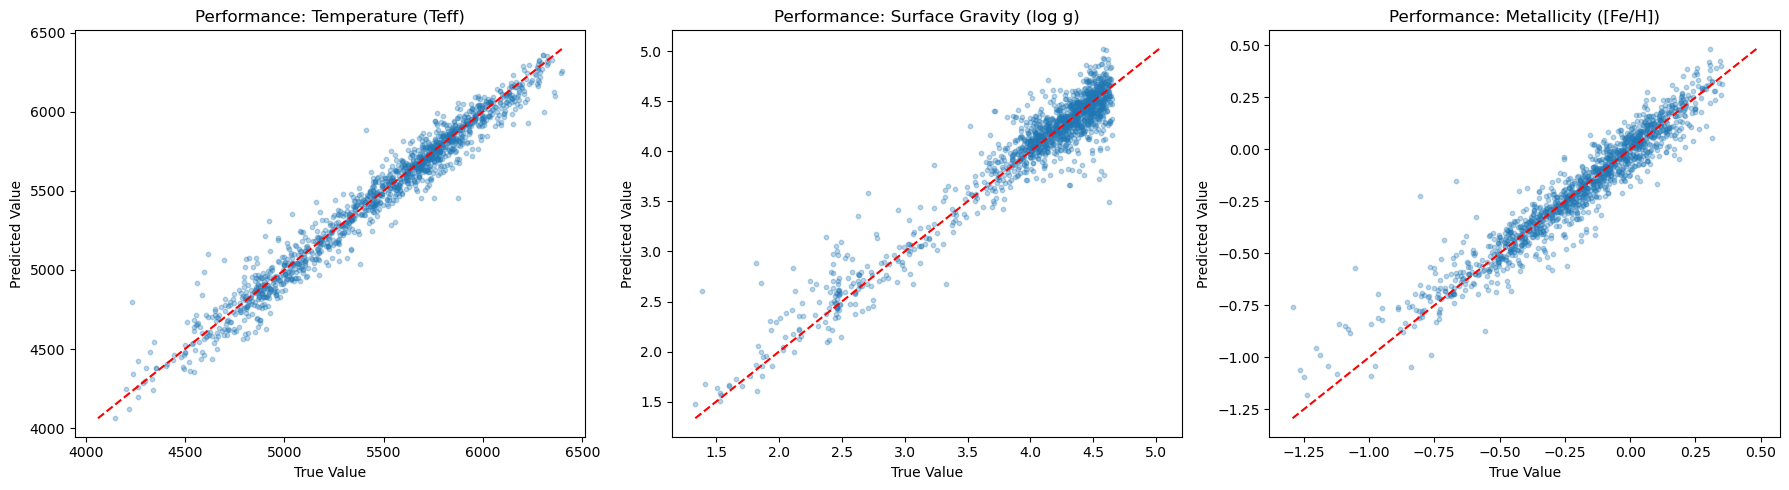

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(params):
    axes[i].scatter(final_true[:, i], final_preds[:, i], alpha=0.3, s=10)

    # Draw the perfect 1:1 line
    low = min(final_true[:, i].min(), final_preds[:, i].min())
    high = max(final_true[:, i].max(), final_preds[:, i].max())
    axes[i].plot([low, high], [low, high], color='red', linestyle='--')

    axes[i].set_title(f'Performance: {name}')
    axes[i].set_xlabel('True Value')
    axes[i].set_ylabel('Predicted Value')

plt.tight_layout()
plt.show()